## EDA

In [ ]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

csv_path = Path.cwd().parent / "data" / "all_fights.csv"
data_frame = pd.read_csv(csv_path)

In [ ]:
# Weight classes in actual weight order instead of alphabetical
wc_order = [
    "Women's Strawweight", "Women's Flyweight", "Women's Bantamweight", "Women's Featherweight",
    "Flyweight", "Bantamweight", "Featherweight", "Lightweight", "Welterweight",
    "Middleweight", "Light Heavyweight", "Heavyweight",
]
wc_order = [w for w in wc_order if w in data_frame["weight_class"].unique()]
counts = data_frame["weight_class"].value_counts()
wc_labels = [f"{w}\n(n={counts[w]})" for w in wc_order]

diff_cols = [c for c in data_frame.columns if c.endswith("_diff") and c != "odds_diff"]

# --- Plot 1: signed diffs (red minus blue) per weight class, one panel per feature ---
long_data_frame = data_frame.melt(id_vars=["weight_class", "red_winner"], value_vars=diff_cols,
                  var_name="feature", value_name="diff")

g = sns.catplot(data=long_data_frame, x="weight_class", y="diff", col="feature", col_wrap=4,
                kind="box", order=wc_order, showfliers=False, sharey=False,
                height=3.2, aspect=1.4, color="steelblue")
for ax in g.axes.flat:
    ax.axhline(0, color="red", lw=0.8, ls="--")
    ax.set_xticks(range(len(wc_order)))
    ax.set_xticklabels(wc_order, rotation=60, ha="right", fontsize=7)
    ax.set_xlabel("")
g.set_titles("{col_name}")
g.figure.suptitle("Red minus blue *_diff by weight class (outliers hidden)", y=1.01)
g.savefig("diff_boxplots_by_weight_class.png", dpi=110, bbox_inches="tight")

# --- Plot 2: heatmap of mean |diff| per weight class, z-scored per feature ---
# |diff| = how mismatched the pairing is, regardless of corner.
# z-scoring each column lets features with different units share one colour scale.
abs_mean = data_frame.groupby("weight_class")[diff_cols].agg(lambda s: s.abs().mean()).loc[wc_order]
z = (abs_mean - abs_mean.mean()) / abs_mean.std()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(z.T, cmap="coolwarm", center=0, annot=abs_mean.T.round(2), fmt="",
            annot_kws={"fontsize": 7}, cbar_kws={"label": "z-score across weight classes"},
            xticklabels=wc_labels, ax=ax)
ax.set_title("Mean |diff| per weight class (numbers = raw mean, colour = relative to other classes)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
fig.savefig("abs_diff_heatmap_by_weight_class.png", dpi=110)

# --- Plot 3 (optional): same boxplots but split by who won ---
# Uncomment to see whether a diff separates winners from losers differently per class.
g2 = sns.catplot(data=long_data_frame, x="weight_class", y="diff", hue="red_winner", col="feature",
                 col_wrap=4, kind="box", order=wc_order, showfliers=False, sharey=False,
                 height=3.2, aspect=1.4)
plt.show()

## Data Cleaning

In [ ]:
# Drop weird stances
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]

# Drop Catch Weight from weight_class (72 entries)
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]

# Drop reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) & (data_frame["reach_diff"] < 40)]

# Drop round_diff outlier (1 entry)
data_frame = data_frame[(data_frame["rounds_diff"] > -100) & (data_frame["rounds_diff"] < 100)]

# Convert red_winner from string to bool
data_frame["red_winner"] = (data_frame["red_winner"].astype(str).str.lower() == "t").astype(int)
# Convert title bout from string to bool'
data_frame["title_bout"] = (data_frame["title_bout"].astype(str).str.lower() == "t").astype(int)

In [6]:
# Retrieve all *_diff features 
diff_features_df = data_frame.filter(regex=r'_diff')

extra_features = [
    "gender", "weight_class", "red_stance", "blue_stance", "red_age", 
    "blue_age", "fight_date", "b_match_wc_rank", "r_match_wc_rank"
]
extra_features_df = data_frame[extra_features]

feature_selected_df = pd.concat([extra_features_df, diff_features_df], axis=1)

# Replace instances of rank 20 (unranked) to 16 so ranking distribution is uniform 
worst_rank = max(feature_selected_df[["b_match_wc_rank", "r_match_wc_rank"]].max().max(), 16) + 1
feature_selected_df["b_match_wc_rank"] = feature_selected_df["b_match_wc_rank"].fillna(worst_rank)
feature_selected_df["r_match_wc_rank"] = feature_selected_df["r_match_wc_rank"].fillna(worst_rank)

# Age gap is more/less impactful depending on where it sits. A 25 v 28 age gap is less significant 
# than it being 32 v 35 and raw age_diff doesn't see that.
feature_selected_df["avg_age"] = (feature_selected_df.red_age + feature_selected_df.blue_age) / 2
feature_selected_df["avg_age_c"] = feature_selected_df["avg_age"] - feature_selected_df["avg_age"].mean()  # center it

# Create a new column that captures the interaction: how much age_diff's
# effect should be amplified or dampened based on how old the pair is on average
feature_selected_df["age_diff_x_avg"] = feature_selected_df["age_diff"] * feature_selected_df["avg_age_c"]

# Drop raw ages since we already have the affect
feature_selected_df = feature_selected_df.drop(columns=["red_age"])
feature_selected_df = feature_selected_df.drop(columns=["blue_age"])

# Drop odds_diff
feature_selected_df = feature_selected_df.drop(columns=["odds_diff"])

#feature_selected_df.info()

#NOTE: class variable??
class_df = data_frame[["red_winner", "fight_date"]]
#class_df.info()

#NOTE: split the data based on fight date
SPLIT_DATE = "2023-06-01"

# Splitting the training data on the specified date
x_training_df = feature_selected_df.loc[feature_selected_df["fight_date"] <= SPLIT_DATE]
x_test_df  = feature_selected_df.loc[feature_selected_df["fight_date"] > SPLIT_DATE]

# Splitting the predictor on the specified date 
y_training_df = class_df.loc[class_df["fight_date"] <= SPLIT_DATE]
y_test_df  = class_df.loc[class_df["fight_date"] > SPLIT_DATE]

# Drop fight_date for the training data and predictor data
x_training_df = x_training_df.drop(columns=["fight_date"])
x_test_df = x_test_df.drop(columns=["fight_date"])

y_training_df = y_training_df.drop(columns=["fight_date"])
y_test_df = y_test_df.drop(columns=["fight_date"])


## Modeling

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

cat_features = ["gender", "weight_class", "red_stance", "blue_stance"]

y_train = y_training_df["red_winner"]
y_test = y_test_df["red_winner"]

## Logistic Regression model

# Collect every non-categorical feature (continuous) into an array
num_features = [c for c in x_training_df.columns if c not in cat_features]

pre_tree = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

params = {
    "clf__n_estimators": [100, 400],
    "clf__max_depth": [4, 12],
    "clf__min_samples_leaf": [15, 45],
    "clf__bootstrap": [True, False],
}


randforrest = Pipeline([
    ("pre", pre_tree),
    ("clf", RandomForestClassifier(n_jobs=-1, random_state=42))
])

grid_search = GridSearchCV(
    estimator=randforrest,
    param_grid=params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(x_training_df, y_train)

best_model = grid_search.best_estimator_
print(grid_search.best_params_)
print(grid_search.best_score_)

proba = best_model.predict_proba(x_test_df)[:, 1]
preds = best_model.predict(x_test_df)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_auc = cross_val_score(best_model, x_training_df,
                         y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()


{'clf__bootstrap': True, 'clf__max_depth': 12, 'clf__min_samples_leaf': 45, 'clf__n_estimators': 400}
0.6152780936635242


## Result analysis

Accuracy Score:  0.6092409240924093
Classification Report 

              precision    recall  f1-score   support

           0       0.63      0.29      0.40       673
           1       0.60      0.86      0.71       842

    accuracy                           0.61      1515
   macro avg       0.62      0.58      0.55      1515
weighted avg       0.62      0.61      0.57      1515

                               Feature  Importance
2                             age_diff   20.434833
16                             td_diff   10.789424
14                        sig_str_diff    9.035004
6                          losses_diff    7.250254
20                      age_diff_x_avg    5.820461
15                        sub_att_diff    4.943573
11                     win_streak_diff    4.580765
7                          rounds_diff    4.398768
3                           reach_diff    3.988214
18                             avg_age    3.235289
19                           avg_age_c    2.960091
1

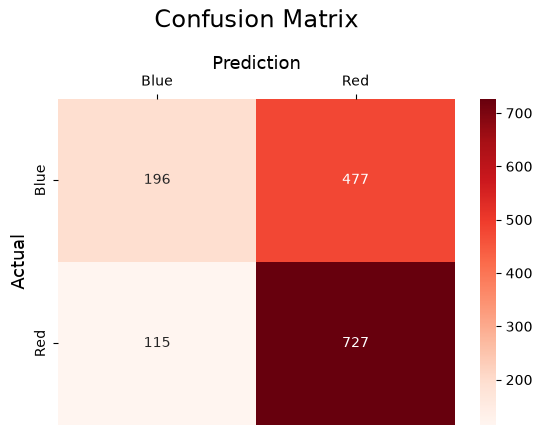

In [10]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, log_loss, roc_auc_score)

print("Accuracy Score: ", accuracy_score(y_test_df, preds))

print("Classification Report \n")
print(classification_report(y_test_df, preds))

encoded_features = best_model.named_steps["pre"].named_transformers_["cat"] 
encoded_names = list(encoded_features.get_feature_names_out(cat_features))
features_names = num_features + encoded_names

importances = (best_model.named_steps["clf"].feature_importances_) * 100
feature_imp_df = pd.DataFrame({"Feature" : features_names, "Importance" : importances}).sort_values("Importance", ascending=False)

print(feature_imp_df)

test_auc = round(roc_auc_score(y_test, proba), 3)
print("Test AUC score: ", test_auc)
print("Log-Loss score: ", log_loss(y_test, proba))
print("ROC AUC score: ", roc_auc_score((y_test == True), proba))

conf_matrix = confusion_matrix(y_test, preds, labels=[False, True])

sns.heatmap(conf_matrix, 
            annot=True,
            fmt="d", 
            cmap="Reds",
            xticklabels=["Blue","Red"],
            yticklabels=["Blue","Red"])

plt.ylabel("Actual", fontsize=13)
plt.title("Confusion Matrix", fontsize=17, pad=20)
plt.gca().xaxis.set_label_position("top") 
plt.xlabel("Prediction", fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.show()
